<a href="https://colab.research.google.com/github/sdashkov/Pet_projects/blob/main/credit_score2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


In [2]:
df = pd.read_csv('credit_risk_dataset.csv')
target = df['loan_status']
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [15]:
CAT_COL = [col for col in df.columns if df[col].dtype != 'int64' and  df[col].dtype != 'float64' and col != 'loan_status']
NUM_COL = [col for col in df.columns if (df[col].dtype == 'int64' or df[col].dtype == 'float64') and col != 'loan_status']
target_col = [col for col in df.columns if col == 'loan_status']
features = [col for col in df.columns if col != 'loan_status']

print(f'Числовые признаки: {NUM_COL}\nКоличество числовых прзнаков: {len(NUM_COL)} \nКатегориальные признаки: {CAT_COL}\nКоличетво категориальных признаков: {len(CAT_COL)}\nВсего прзнаков: {len(NUM_COL) + len(CAT_COL)}')

Числовые признаки: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Количество числовых прзнаков: 7 
Категориальные признаки: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
Количетво категориальных признаков: 4
Всего прзнаков: 11


## **Графики**


### **Числовые признаки**

In [16]:
corr_matrix = df[NUM_COL].corr(method = 'spearman')
corr_matrix

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.144972,0.107211,0.064382,0.012246,-0.057991,0.805512
person_income,0.144972,1.000000,0.213347,0.406586,-0.034283,-0.366881,0.091865
person_emp_length,0.107211,0.213347,1.000000,0.110051,-0.066426,-0.058310,0.069790
loan_amnt,0.064382,0.406586,0.110051,1.000000,0.106307,0.653633,0.042085
loan_int_rate,0.012246,-0.034283,-0.066426,0.106307,1.000000,0.124217,0.013968
loan_percent_income,-0.057991,-0.366881,-0.058310,0.653633,0.124217,1.000000,-0.037114
cb_person_cred_hist_length,0.805512,0.091865,0.069790,0.042085,0.013968,-0.037114,1.000000


<Axes: ylabel='loan_status'>

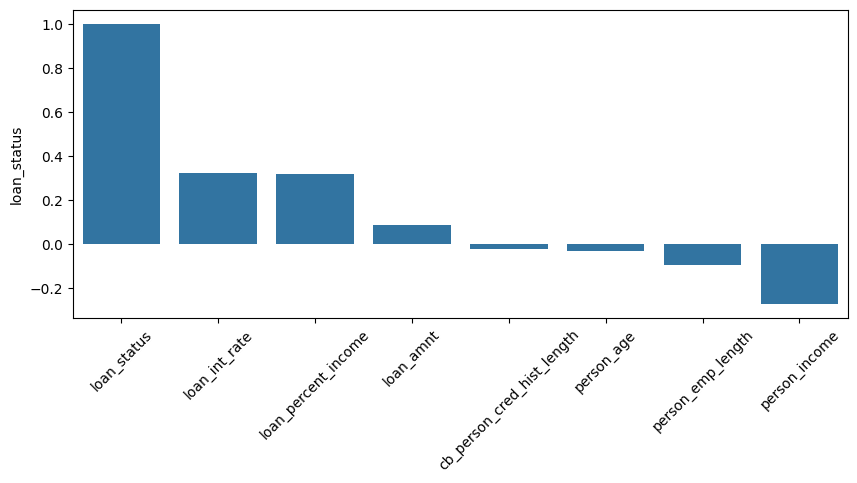

In [17]:
target_corr = df.corr(method = 'spearman', numeric_only = 'True')['loan_status'].sort_values(ascending=False)
plt.figure(figsize = (10, 4))
plt.xticks(rotation = 45)
sns.barplot(target_corr)

In [18]:
corr_matrix_2 = df.corr(method = 'spearman', numeric_only = 'True')
corr_matrix_2

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.144972,0.107211,0.064382,0.012246,-0.033354,-0.057991,0.805512
person_income,0.144972,1.000000,0.213347,0.406586,-0.034283,-0.272131,-0.366881,0.091865
person_emp_length,0.107211,0.213347,1.000000,0.110051,-0.066426,-0.097558,-0.058310,0.069790
loan_amnt,0.064382,0.406586,0.110051,1.000000,0.106307,0.084032,0.653633,0.042085
loan_int_rate,0.012246,-0.034283,-0.066426,0.106307,1.000000,0.320062,0.124217,0.013968
loan_status,-0.033354,-0.272131,-0.097558,0.084032,0.320062,1.000000,0.316115,-0.023779
loan_percent_income,-0.057991,-0.366881,-0.058310,0.653633,0.124217,0.316115,1.000000,-0.037114
cb_person_cred_hist_length,0.805512,0.091865,0.069790,0.042085,0.013968,-0.023779,-0.037114,1.000000


<Axes: title={'center': 'Матрица корреляции признаков кредитного риска'}>

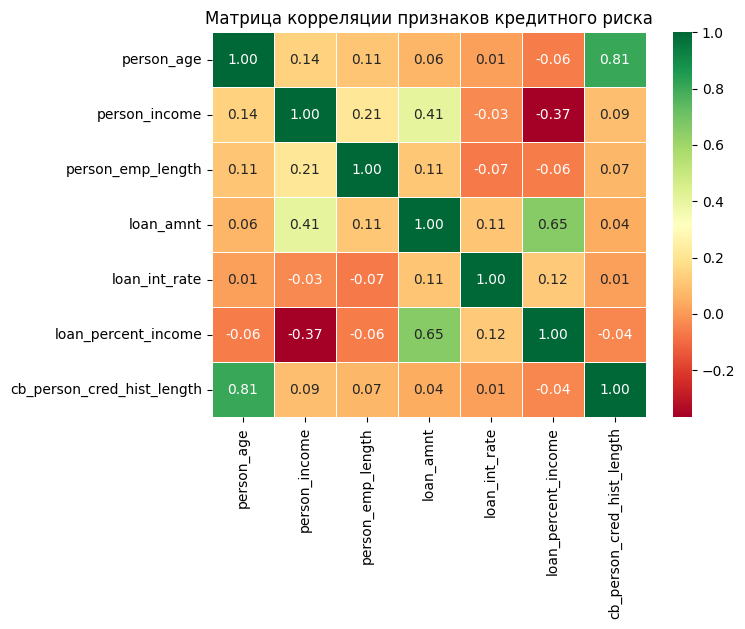

In [19]:
plt.figure(figsize=(7, 5))
plt.title('Матрица корреляции признаков кредитного риска')
sns.heatmap(corr_matrix, annot = True, cmap = 'RdYlGn', fmt = '.2f', linewidths = 0.5)

,count
loan_status,
0,25473
1,7108


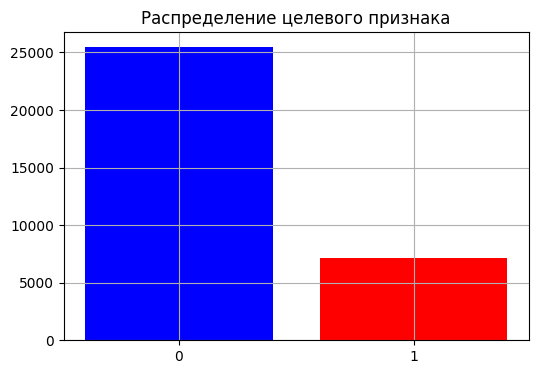

In [23]:
target = df['loan_status']

plt.figure(figsize = (6, 4))
plt.bar(target.unique(),
        target.value_counts(sort = False),
        color = ['r', 'b'])

plt.xticks(target.unique())
plt.title('Распределение целевого признака')
plt.grid()
target.value_counts()

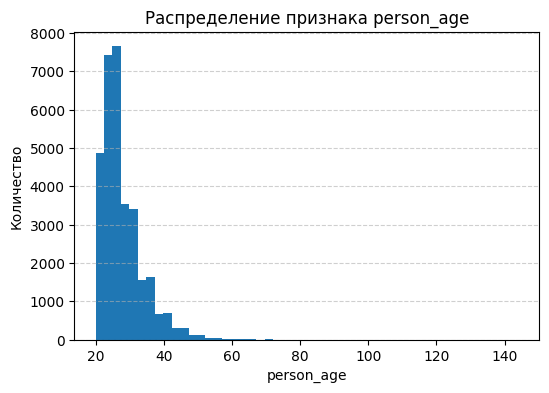

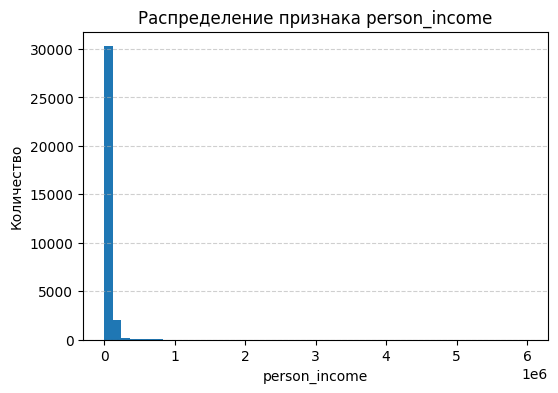

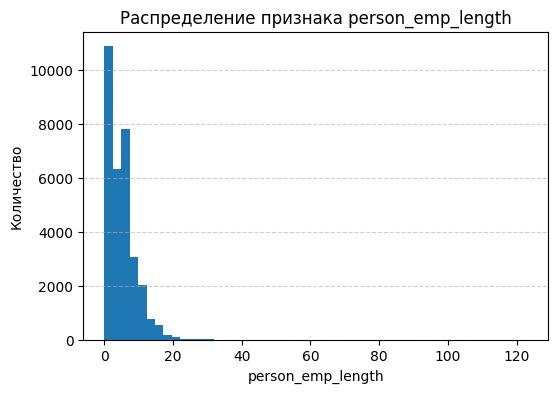

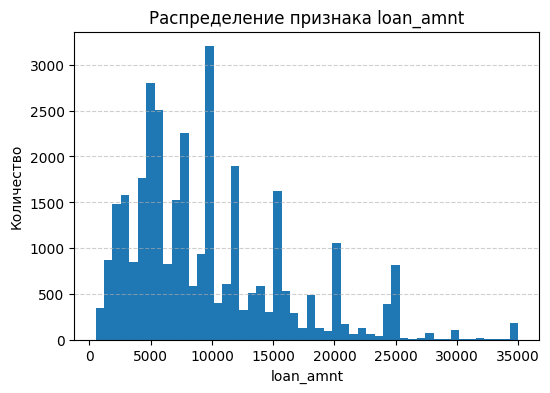

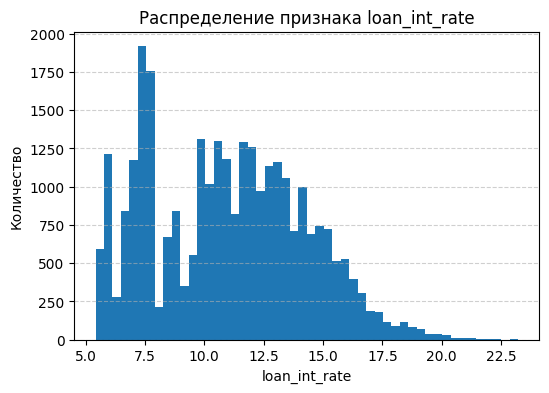

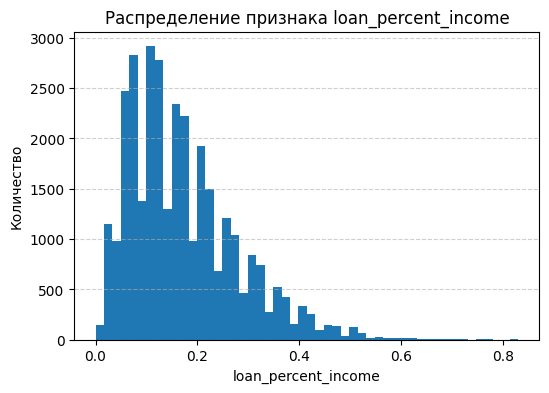

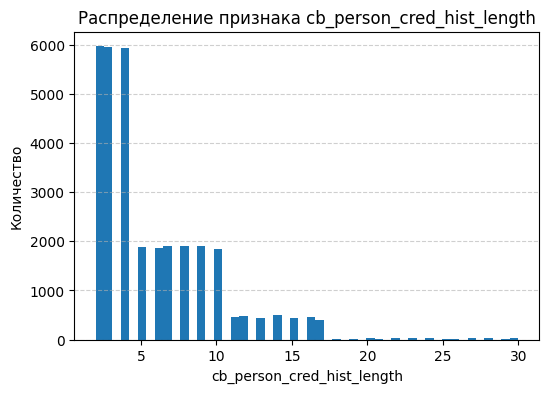

In [24]:
for col in NUM_COL:
  plt.figure(figsize = (6, 4))
  plt.hist(df[col], bins = 50)
  plt.title(f'Распределение признака {col}')
  plt.xlabel(col)
  plt.ylabel('Количество')
  plt.grid(axis = 'y', linestyle = '--', alpha = 0.6)

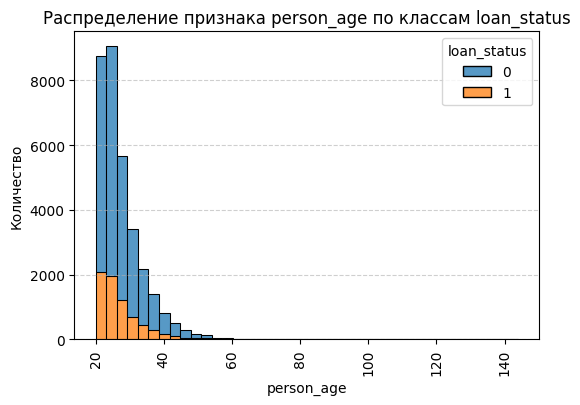

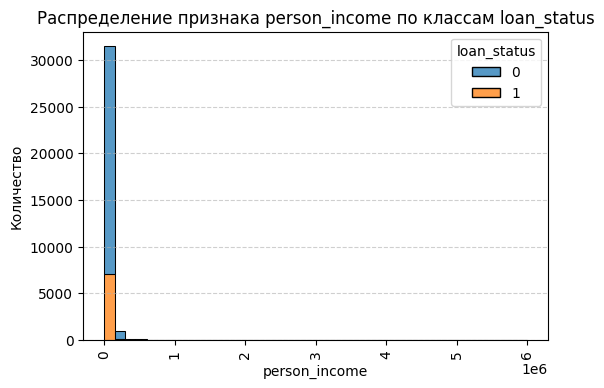

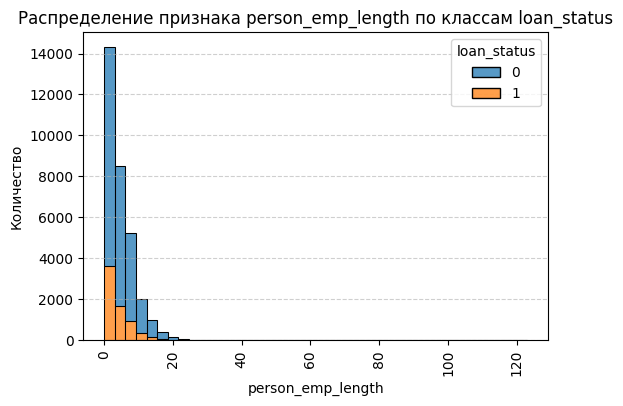

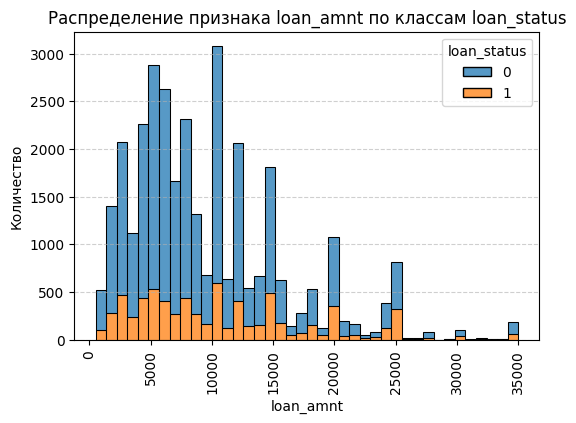

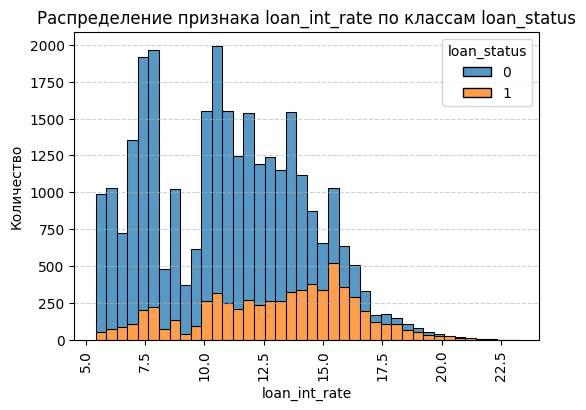

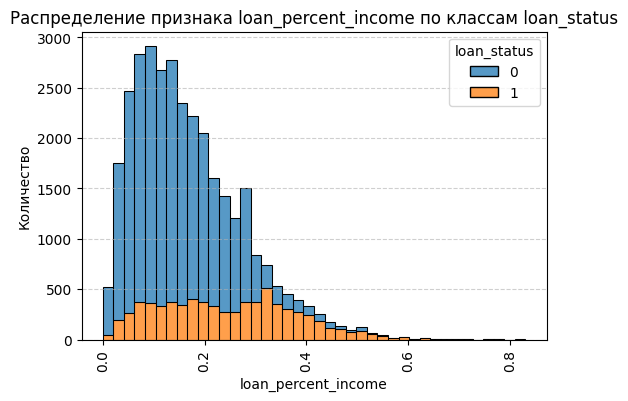

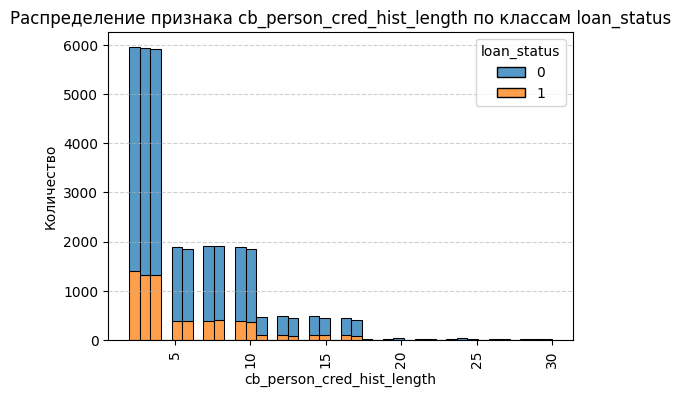

In [25]:
for col in NUM_COL:
  plt.figure(figsize = (6, 4))
  sns.histplot(data = df,
               x = col,
               hue = target,
               bins = 40,
               multiple = 'stack')

  plt.title(f'Распределение признака {col} по классам {target.name}')
  plt.ylabel('Количество')
  plt.grid(axis = 'y', linestyle = '--', alpha = 0.6)

  plt.xticks(rotation = 90)

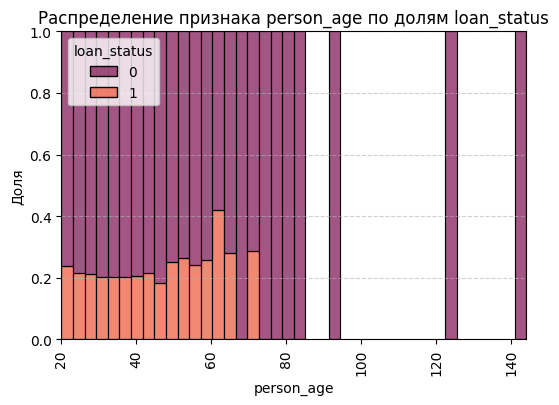

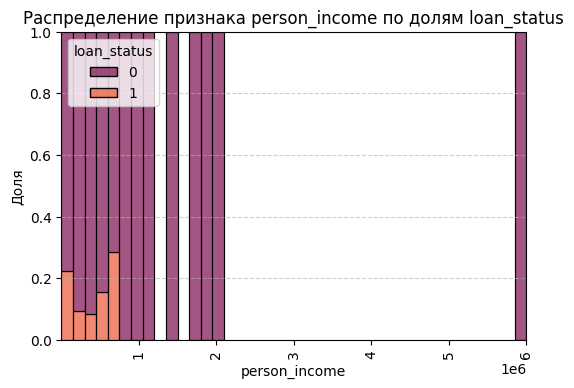

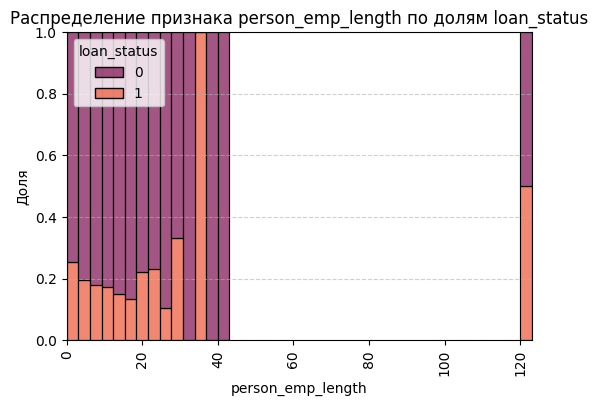

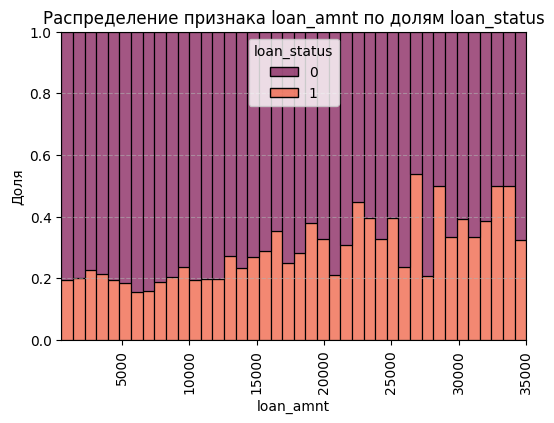

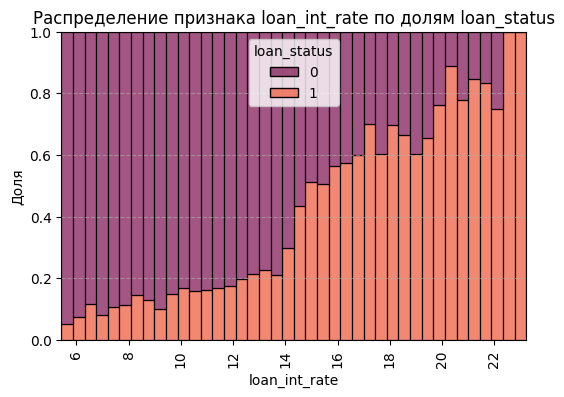

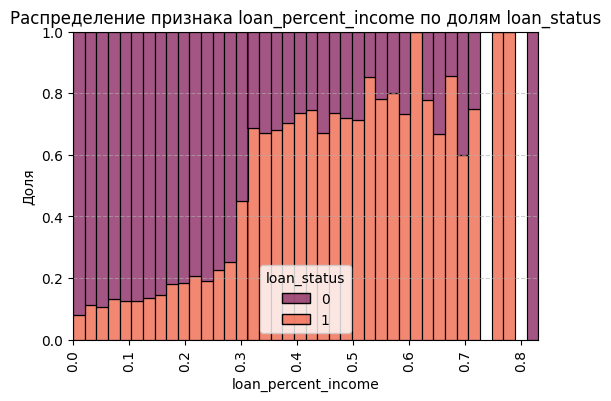

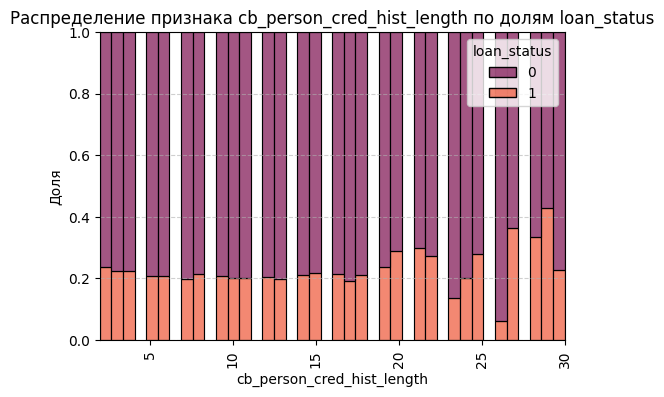

In [26]:
for col in NUM_COL:
  plt.figure(figsize = (6, 4))
  sns.histplot(data = df,
               x = col,
               hue = target,
               bins = 40,
               multiple = 'fill',
               palette = 'rocket')

  plt.title(f'Распределение признака {col} по долям {target.name}')
  plt.ylabel('Доля')
  plt.grid(axis = 'y', linestyle = '--', alpha = 0.6)

  plt.xticks(rotation = 90)

### **Категориальные признаки**

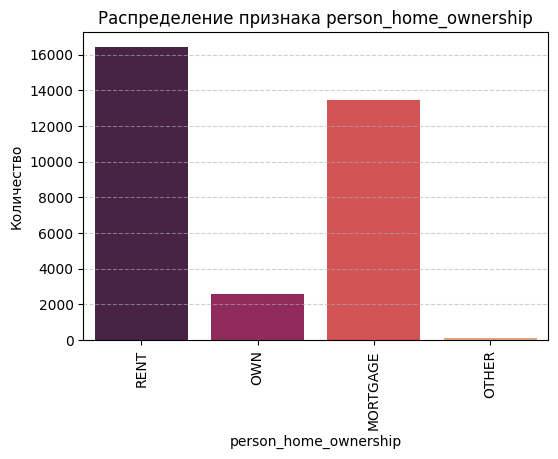

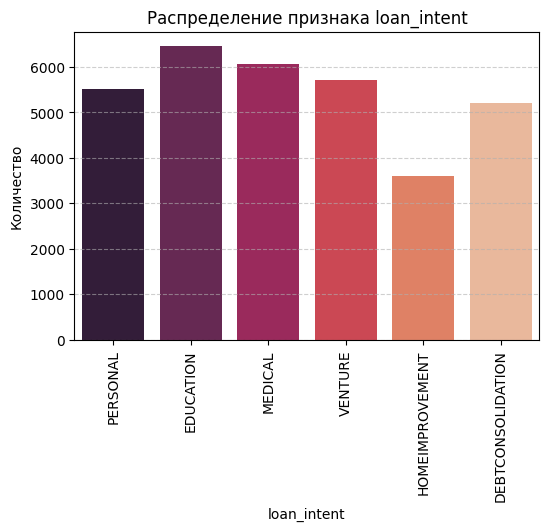

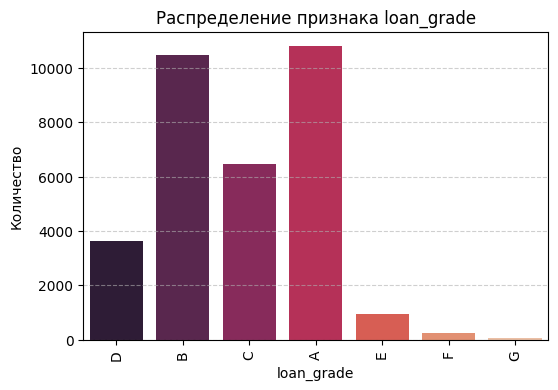

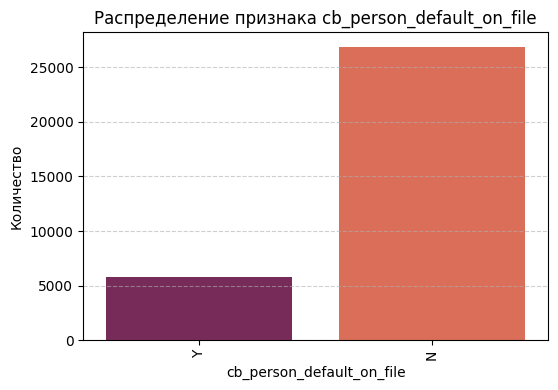

In [27]:
for col in CAT_COL:
  plt.figure(figsize = (6, 4))
  sns.countplot(x = col,
                data = df,
                hue = col,
                legend = False,
                palette = 'rocket')
  plt.title(f'Распределение признака {col}')
  plt.grid(axis = 'y', linestyle = '--', alpha = 0.6)
  plt.ylabel('Количество')
  plt.xticks(rotation = 90)

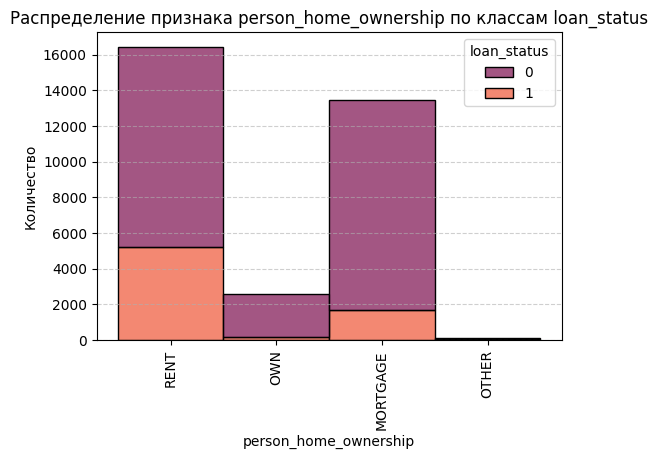

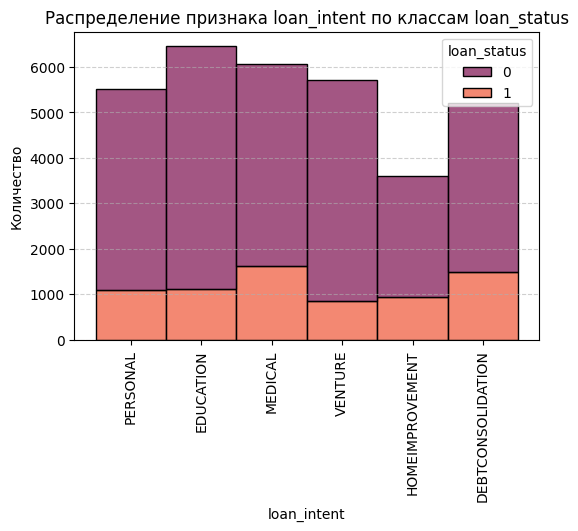

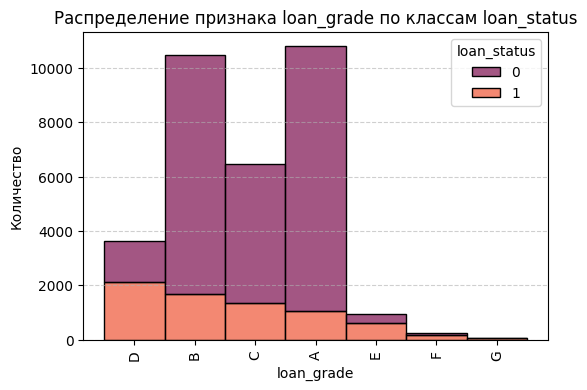

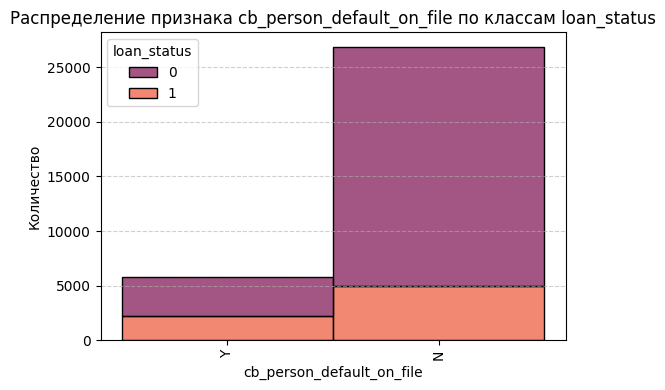

In [28]:
for col in CAT_COL:
  plt.figure(figsize = (6, 4))
  sns.histplot(data = df,
               x = col,
               hue = target,
               bins = 40,
               multiple = 'stack',
               palette = 'rocket')

  plt.title(f'Распределение признака {col} по классам {target.name}')
  plt.ylabel('Количество')
  plt.grid(axis = 'y', linestyle = '--', alpha = 0.6)

  plt.xticks(rotation = 90)

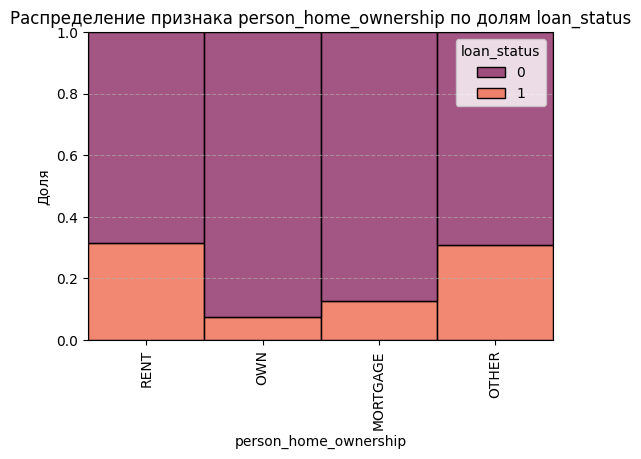

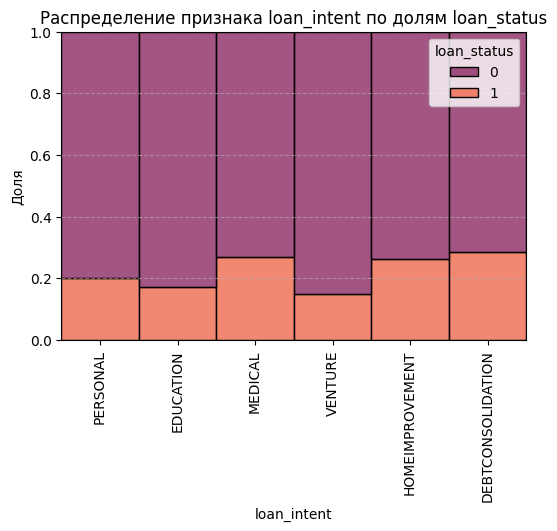

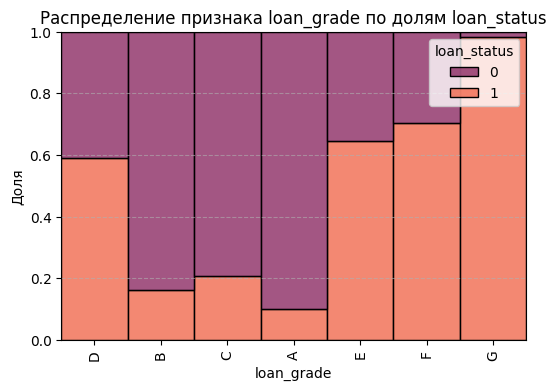

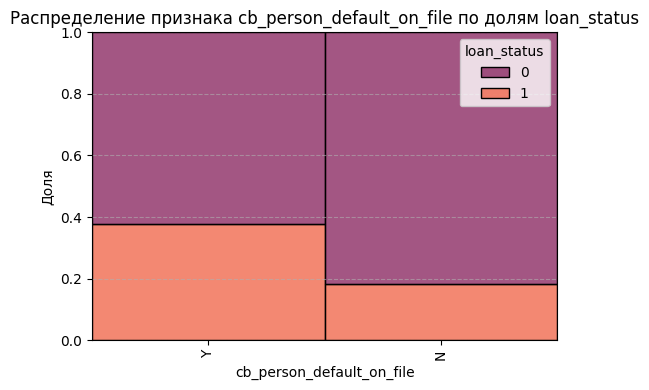

In [29]:
for col in CAT_COL:
  plt.figure(figsize = (6, 4))
  sns.histplot(data = df,
               x = col,
               hue = target,
               bins = 40,
               multiple = 'fill',
               palette = 'rocket')

  plt.title(f'Распределение признака {col} по долям {target.name}')
  plt.ylabel('Доля')
  plt.grid(axis = 'y', linestyle = '--', alpha = 0.6)

  plt.xticks(rotation = 90)

# **EDA**

# **Очистка**

## Дубликаты

In [30]:
df = df.drop_duplicates()
df.shape

(32416, 12)

## Обработка пропущенных значений

In [31]:
for col in NUM_COL:
  print(col, df[col].isna().sum())

person_age 0
person_income 0
person_emp_length 887
loan_amnt 0
loan_int_rate 3095
loan_percent_income 0
cb_person_cred_hist_length 0


In [32]:
for col in NUM_COL:
  df[col] = df[col].fillna(df[col].median())
print(df[col].isna().sum())

0


In [33]:
for col in CAT_COL:
  print(col, df[col].isna().sum())

person_home_ownership 0
loan_intent 0
loan_grade 0
cb_person_default_on_file 0


In [34]:
for col in CAT_COL:
  df[col] = df[col].fillna(df[col].mode())

## Обработка аномальных значений

In [35]:
for col in NUM_COL:
  data = df[col]
  threshold = np.percentile(data.dropna(), 95)
  data = np.where(data > threshold, threshold, data)
  df[col] = data


In [36]:
df = df[df['person_age'] > 18]
df = df[df['person_age'] < 100]
df = df[df["person_income"] > 0]
df = df[df["loan_amnt"] > 0]

## Обработка выбрсов

In [37]:
def z_score(x):

  x = np.array(x)
  m = np.mean(x)
  s = np.std(x)
  z_scores = (x - m) / s

  outliers = x[np.abs(z_scores) > 3]
  outliers_count = len(outliers)
  return outliers, outliers_count

for col in NUM_COL:
  outliers, count = z_score(df[col])
  print(col, count)

person_age 0
person_income 0
person_emp_length 0
loan_amnt 0
loan_int_rate 0
loan_percent_income 0
cb_person_cred_hist_length 0


In [38]:
def IQR(x):

  x = np.array(x)

  Q1 = np.quantile(x, 0.25)
  Q3 = np.quantile(x, 0.75)

  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = x[(x < lower_bound) | (x > upper_bound)]
  outliers_count = len(outliers)

  return outliers, outliers_count

for col in NUM_COL:
  outliers_iqr, count_iqr = IQR(df[col])
  print(col, count_iqr)

person_age 0
person_income 0
person_emp_length 0
loan_amnt 1679
loan_int_rate 0
loan_percent_income 0
cb_person_cred_hist_length 0


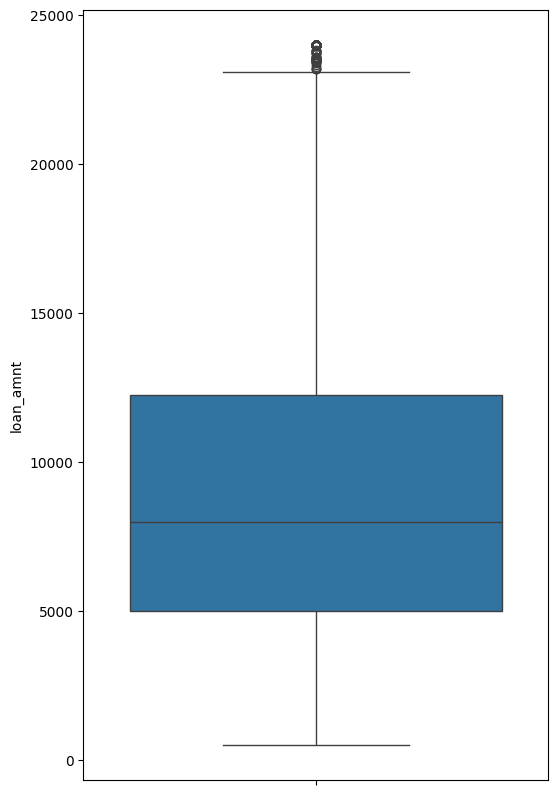

In [41]:
plt.figure(figsize = (6, 10))
sns.boxplot(df['loan_amnt'])

plt.show()

# **Feature engineering**

In [42]:
df['age_minus_hist'] = df['person_age'] - df['cb_person_cred_hist_length']
df = df.drop(columns = ['person_age','cb_person_cred_hist_length'])

In [45]:
NUM_COL = [col for col in df.columns if (df[col].dtype == 'int64' or df[col].dtype == 'float64') and col != 'loan_status']
NUM_COL

['person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'age_minus_hist']

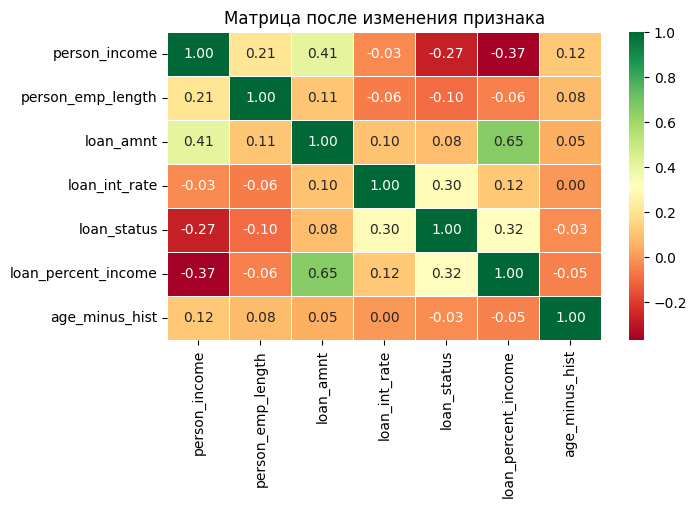

In [46]:
corr_matrix_2 = df.corr(method = 'spearman', numeric_only = True)
plt.figure(figsize=(7, 4))
sns.heatmap(corr_matrix_2, annot = True, cmap = 'RdYlGn', fmt = '.2f', linewidths = 0.5, )
plt.title('Матрица после изменения признака')
plt.show()

## Кодировка признаков

In [47]:
df_catboost = df.copy()
# Сохранение исходного датасета без кодировки категорипльных признаков

In [48]:
for col in df[CAT_COL]:
  print(f'{col}: {df[col].unique()}')

person_home_ownership: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
loan_intent: ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
loan_grade: ['D' 'B' 'C' 'A' 'E' 'F' 'G']
cb_person_default_on_file: ['Y' 'N']


In [49]:
df2 = df.copy()
map_dict = {'Y': 0,
            'N': 1}
marks = {'G': 0,
         'F': 1,
         'E': 2,
         'D': 3,
         'C': 4,
         'B': 5,
         'A': 6}

In [50]:
df2['loan_grade'] = df2['loan_grade'].map(marks)
df2

,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,age_minus_hist
0,59000.0,RENT,12.0,PERSONAL,3,24000.0,16.02,1,0.38,Y,19.0
1,9600.0,OWN,5.0,EDUCATION,5,1000.0,11.14,0,0.10,N,19.0
2,9600.0,MORTGAGE,1.0,MEDICAL,4,5500.0,12.87,1,0.38,N,22.0
3,65500.0,RENT,4.0,MEDICAL,4,24000.0,15.23,1,0.38,N,21.0
4,54400.0,RENT,8.0,MEDICAL,4,24000.0,14.27,1,0.38,Y,20.0
...,...,...,...,...,...,...,...,...,...,...,...
32576,53000.0,MORTGAGE,1.0,PERSONAL,4,5800.0,13.16,0,0.11,N,26.0
32577,120000.0,MORTGAGE,4.0,PERSONAL,6,17625.0,7.49,0,0.15,N,26.0
32578,76000.0,RENT,3.0,HOMEIMPROVEMENT,5,24000.0,10.99,1,0.38,N,26.0
32579,138000.0,MORTGAGE,5.0,PERSONAL,5,15000.0,11.48,0,0.10,N,26.0


In [51]:
df2['cb_person_default_on_file'] = df2['cb_person_default_on_file'].map(map_dict)
df2

,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,age_minus_hist
0,59000.0,RENT,12.0,PERSONAL,3,24000.0,16.02,1,0.38,0,19.0
1,9600.0,OWN,5.0,EDUCATION,5,1000.0,11.14,0,0.10,1,19.0
2,9600.0,MORTGAGE,1.0,MEDICAL,4,5500.0,12.87,1,0.38,1,22.0
3,65500.0,RENT,4.0,MEDICAL,4,24000.0,15.23,1,0.38,1,21.0
4,54400.0,RENT,8.0,MEDICAL,4,24000.0,14.27,1,0.38,0,20.0
...,...,...,...,...,...,...,...,...,...,...,...
32576,53000.0,MORTGAGE,1.0,PERSONAL,4,5800.0,13.16,0,0.11,1,26.0
32577,120000.0,MORTGAGE,4.0,PERSONAL,6,17625.0,7.49,0,0.15,1,26.0
32578,76000.0,RENT,3.0,HOMEIMPROVEMENT,5,24000.0,10.99,1,0.38,1,26.0
32579,138000.0,MORTGAGE,5.0,PERSONAL,5,15000.0,11.48,0,0.10,1,26.0


In [52]:
df2 = pd.get_dummies(df2,
                     columns = ['person_home_ownership', 'loan_intent'],
                     drop_first = True,
                     dtype = 'int')


In [53]:
df2

,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,age_minus_hist,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,59000.0,12.0,3,24000.0,16.02,1,0.38,0,19.0,0,0,1,0,0,0,1,0
1,9600.0,5.0,5,1000.0,11.14,0,0.10,1,19.0,0,1,0,1,0,0,0,0
2,9600.0,1.0,4,5500.0,12.87,1,0.38,1,22.0,0,0,0,0,0,1,0,0
3,65500.0,4.0,4,24000.0,15.23,1,0.38,1,21.0,0,0,1,0,0,1,0,0
4,54400.0,8.0,4,24000.0,14.27,1,0.38,0,20.0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,53000.0,1.0,4,5800.0,13.16,0,0.11,1,26.0,0,0,0,0,0,0,1,0
32577,120000.0,4.0,6,17625.0,7.49,0,0.15,1,26.0,0,0,0,0,0,0,1,0
32578,76000.0,3.0,5,24000.0,10.99,1,0.38,1,26.0,0,0,1,0,1,0,0,0
32579,138000.0,5.0,5,15000.0,11.48,0,0.10,1,26.0,0,0,0,0,0,0,1,0


# **Разбиение данных**

In [54]:
df2_features = [col for col in df2.columns if col != 'loan_status']
X = df2[df2_features]
y = df2['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.3,
                                                    random_state = 42,
                                                    stratify = y)


# **baseline_модель** - Логистическая регрессия

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    random_state = 42,
    class_weight='balanced')

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [56]:
from sklearn.metrics import classification_report
y_pred = log_reg.predict(X_train_scaled)
y_pred_proba = log_reg.predict_proba(X_train_scaled)[:, 1]

print("Точность:", log_reg.score(X_train_scaled, y_train))
print("ROC-AUC:", roc_auc_score(y_train, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_train, y_pred))

Точность: 0.7872284165528183
ROC-AUC: 0.8639922080040242

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.79      0.85     17729
           1       0.51      0.79      0.62      4962

    accuracy                           0.79     22691
   macro avg       0.72      0.79      0.74     22691
weighted avg       0.84      0.79      0.80     22691



In [57]:
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Точность:", log_reg.score(X_test_scaled, y_test))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Точность: 0.7880719794344473
ROC-AUC: 0.8653854792906307

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.79      0.85      7598
           1       0.51      0.78      0.62      2127

    accuracy                           0.79      9725
   macro avg       0.72      0.79      0.74      9725
weighted avg       0.84      0.79      0.80      9725



# **Улучшение модели**

In [58]:
feature_importance = pd.DataFrame({'feature': X_train.columns,
                                   'coef': log_reg.coef_[0]})
print(feature_importance.sort_values(by = 'coef', ascending = False))

                        feature      coef
5           loan_percent_income  1.237746
10   person_home_ownership_RENT  0.292448
12  loan_intent_HOMEIMPROVEMENT  0.080376
6     cb_person_default_on_file  0.039170
8   person_home_ownership_OTHER  0.008112
7                age_minus_hist -0.006783
1             person_emp_length -0.010430
13          loan_intent_MEDICAL -0.031630
4                 loan_int_rate -0.069052
0                 person_income -0.121290
14         loan_intent_PERSONAL -0.189736
11        loan_intent_EDUCATION -0.274703
15          loan_intent_VENTURE -0.395456
9     person_home_ownership_OWN -0.436956
3                     loan_amnt -0.548391
2                    loan_grade -1.117849


## Градиентный бустинг

In [59]:
from sklearn.ensemble import GradientBoostingClassifier
GB = GradientBoostingClassifier()

GB.fit(X_train, y_train)

GradientBoostingClassifier()

In [64]:
y_pred_gb = GB.predict(X_train)
y_pred_proba_gb = GB.predict_proba(X_train)[:, 1]

print("Точность:", GB.score(X_train, y_train))
print("ROC-AUC:", roc_auc_score(y_train, y_pred_proba_gb))
print("\nClassification Report:")
print(classification_report(y_train, y_pred_gb))

Точность: 0.927768718875325
ROC-AUC: 0.9334977471856787

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     17729
           1       0.94      0.71      0.81      4962

    accuracy                           0.93     22691
   macro avg       0.93      0.85      0.88     22691
weighted avg       0.93      0.93      0.92     22691



In [65]:
y_pred_gb = GB.predict(X_test)
y_pred_proba_gb = GB.predict_proba(X_test)[:, 1]

print("Точность:", GB.score(X_test, y_test))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_gb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Точность: 0.9268894601542417
ROC-AUC: 0.9290096631719456

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.95      7598
           1       0.93      0.72      0.81      2127

    accuracy                           0.93      9725
   macro avg       0.93      0.85      0.88      9725
weighted avg       0.93      0.93      0.92      9725



In [96]:
importances = pd.DataFrame({'Признак': X_train.columns,
                        'Важность признака': GB.feature_importances_})
importances = importances.sort_values(by = 'Важность признака', ascending = False)
importances

,Признак,Важность признака
5,loan_percent_income,0.322286
2,loan_grade,0.277120
10,person_home_ownership_RENT,0.167112
0,person_income,0.117498
1,person_emp_length,0.026103
9,person_home_ownership_OWN,0.021535
13,loan_intent_MEDICAL,0.019924
12,loan_intent_HOMEIMPROVEMENT,0.014033
11,loan_intent_EDUCATION,0.008711
4,loan_int_rate,0.008237
